In [1]:
# ============================================================
# Instalación de paquetes
# ============================================================

!pip install -q mesa
!pip install -q solara

# ============================================================
# Librerías básicas
# ============================================================

import mesa
import solara

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# ============================================================
# Configuración general
# ============================================================

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["axes.grid"] = False

# Para reproducibilidad
SEED = 12345
rng = np.random.default_rng(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.1/275.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.0/269.0 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 93.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


In [2]:
# ============================================================
# AGENTE
# ============================================================

class Persona(mesa.Agent):
    """
    Agente del modelo matricial de Schelling.

    Cada agente tiene un tipo, por ahora tipo 1 o tipo -1.
    La incomodidad local se calcula usando una matriz H de incomodidad.
    """

    def __init__(self, model, tipo: int, se_ha_movido: bool = False) -> None:
        super().__init__(model)
        self.tipo = tipo
        self.se_ha_movido = se_ha_movido

    def incomodidad(self, pos, tipo=None):
        """
        Calcula la incomodidad local inducida por H si un agente de tipo `tipo`
        estuviera en la posición `pos`.

        Si tipo=None, se usa el tipo propio del agente.

        Convención:
        Si la posición no tiene vecinos ocupados, la incomodidad es 0.
        """

        if tipo is None:
            tipo = self.tipo

        vecindad = self.model.grid.get_neighbors(
            pos,
            moore=True,
            include_center=False
        )

        n_vecinos = len(vecindad)

        if n_vecinos == 0:
            return 0.0

        i = self.model.tipo_to_idx[tipo]

        total = 0.0
        for vecino in vecindad:
            j = self.model.tipo_to_idx[vecino.tipo]
            total += self.model.H[i, j]

        return total / n_vecinos

    def incomodidad_clasica(self, pos, tipo=None):
        """
        Calcula la incomodidad clásica:
        proporción de vecinos ocupados que son de tipo distinto. No como conteo entero de vecinos “problemáticos”,

        Esta función no es necesaria para la dinámica matricial,
        pero es útil para comparar con el modelo clásico.
        """

        if tipo is None:
            tipo = self.tipo

        vecindad = self.model.grid.get_neighbors(
            pos,
            moore=True,
            include_center=False
        )

        n_vecinos = len(vecindad)

        if n_vecinos == 0:
            return 0.0

        distintos = 0
        for vecino in vecindad:
            if vecino.tipo != tipo:
                distintos += 1

        return distintos / n_vecinos

    def tolerancia(self):
        """
        Devuelve el umbral de tolerancia del agente.

        Permite dos opciones:
        1. Un único umbral para todos los agentes:
           self.model.tolerance = tau

        2. Umbrales por tipo:
           self.model.tolerance = {1: tau_1, -1: tau_menos_1}
        """

        if isinstance(self.model.tolerance, dict):
            return self.model.tolerance[self.tipo]

        return self.model.tolerance

    def esta_comodo(self, pos=None):
        """
        Determina si el agente está cómodo en una posición dada.
        Si pos=None, evalúa su posición actual.
        """

        if pos is None:
            pos = self.pos

        return self.incomodidad(pos, self.tipo) <= self.tolerancia()

    def move(self):
        """
        Regla de movimiento.

        El agente se mueve solo si está incómodo. Busca posiciones vacías,
        aumentando progresivamente el radio de búsqueda, y se mueve a una
        posición que reduzca estrictamente su incomodidad.
        """

        self.se_ha_movido = False

        incomodidad_base = self.incomodidad(self.pos, self.tipo)

        if incomodidad_base <= self.tolerancia():
            return

        possible_steps = []
        radio = 0
        max_iteraciones = max(self.model.grid.width, self.model.grid.height) // 2 + 1

        while not possible_steps and radio < max_iteraciones:
            radio += 1

            vecindario = self.model.grid.get_neighborhood(
                self.pos,
                moore=True,
                include_center=False,
                radius=radio
            )

            empty_steps = [
                step for step in vecindario
                if self.model.grid.is_cell_empty(step)
            ]

            possible_steps = [
                step for step in empty_steps
                if self.incomodidad(step, self.tipo) < incomodidad_base
            ]

        if possible_steps:
            new_position = self.model.random.choice(possible_steps)
            self.model.grid.move_agent(self, new_position)
            self.se_ha_movido = True

    def step(self):
        """
        Acción del agente en cada paso temporal.
        """

        self.move()

In [3]:
# ============================================================
# MODELO
# ============================================================

class Modelo_Desplazamiento(mesa.Model):
    """
    Modelo matricial de Schelling para dos tipos de agentes: 1 y -1.

    La incomodidad local se calcula mediante una matriz H de tamaño 2x2.

    Orden de tipos:
        tipo  1  -> índice 0
        tipo -1  -> índice 1

    Por tanto,

        H[0,0] = incomodidad de un agente tipo  1 frente a vecino tipo  1
        H[0,1] = incomodidad de un agente tipo  1 frente a vecino tipo -1
        H[1,0] = incomodidad de un agente tipo -1 frente a vecino tipo  1
        H[1,1] = incomodidad de un agente tipo -1 frente a vecino tipo -1
    """

    def __init__(
        self,
        N1: int,
        Nm1: int,
        width: int,
        height: int,
        H,
        tol,
        seed=None,
        collect_initial: bool = True
    ):
        super().__init__(seed=seed)

        # ----------------------------
        # Parámetros básicos
        # ----------------------------

        self.N1 = N1
        self.Nm1 = Nm1
        self.num_agents = N1 + Nm1

        self.width = width
        self.height = height

        if self.num_agents > width * height:
            raise ValueError("El número de agentes no puede exceder el número de celdas.")

        # ----------------------------
        # Tipos y matriz H
        # ----------------------------

        self.tipos = [1, -1]

        self.tipo_to_idx = {
            1: 0,
            -1: 1
        }

        self.H = np.array(H, dtype=float)

        if self.H.shape != (2, 2):
            raise ValueError("La matriz H debe tener tamaño 2x2.")

        # Permite una tolerancia común o tolerancias por tipo.
        #
        # Ejemplo tolerancia común:
        #     tol = 0.4
        #
        # Ejemplo tolerancia por tipo:
        #     tol = {1: 0.4, -1: 0.6}

        self.tolerance = tol

        # ----------------------------
        # Espacio
        # ----------------------------

        self.grid = mesa.space.SingleGrid(
            width,
            height,
            torus=True
        )

        # ----------------------------
        # Estado dinámico
        # ----------------------------

        self.running = True
        self.in_equilibrium = False
        self.steps_to_equilibrium = 0
        self.moved_count = 0

        # ----------------------------
        # Métricas básicas
        # ----------------------------

        self.unsatisfied_count = 0
        self.unsatisfied_by_type = {
            1: 0,
            -1: 0
        }

        self.mean_discomfort = 0.0
        self.mean_discomfort_by_type = {
            1: 0.0,
            -1: 0.0
        }

        self.contact_measure = {
            1: {1: 0.0, -1: 0.0},
            -1: {1: 0.0, -1: 0.0}
        }

        # ------------------------------------------------------
        # Espacio reservado para métricas futuras
        # ------------------------------------------------------
        #
        # Algunas métricas que podríamos agregar más adelante:
        #
        # 1. Índice global de segregación.
        # 2. Tamaño medio de clústeres por tipo.
        # 3. Número de componentes conexas por tipo.
        # 4. Distribución de incomodidades locales.
        # 5. Incomodidad total del sistema.
        # 6. Exposición promedio de cada grupo al otro grupo.
        # 7. Varianza de la composición local.
        # 8. Fracción de agentes con vecindario vacío.
        # 9. Tiempo hasta alcanzar cierto porcentaje de comodidad.
        # 10. Métricas específicas para comparar regímenes:
        #     homofílico, heterofílico, neutral o mixto.

        # ----------------------------
        # Recolector de datos
        # ----------------------------

        self.datacollector = mesa.DataCollector(
            model_reporters={
                "Steps_to_Equilibrium": "steps_to_equilibrium",
                "In_Equilibrium": "in_equilibrium",
                "Moved_Total": lambda m: m.moved_count,

                # Insatisfechos
                "Unsatisfied_Total": lambda m: m.unsatisfied_count,
                "Unsatisfied_1": lambda m: m.unsatisfied_by_type[1],
                "Unsatisfied_-1": lambda m: m.unsatisfied_by_type[-1],

                # Incomodidad promedio
                "Mean_Discomfort": lambda m: m.mean_discomfort,
                "Mean_Discomfort_1": lambda m: m.mean_discomfort_by_type[1],
                "Mean_Discomfort_-1": lambda m: m.mean_discomfort_by_type[-1],

                # Contactos dirigidos normalizados
                "C_11": lambda m: m.contact_measure[1][1],
                "C_1m1": lambda m: m.contact_measure[1][-1],
                "C_m11": lambda m: m.contact_measure[-1][1],
                "C_m1m1": lambda m: m.contact_measure[-1][-1],
            }
        )

        # ----------------------------
        # Creación de agentes
        # ----------------------------

        agentes_creados = []


        for _ in range(N1):
            agentes_creados.append(
                Persona(
                    model=self,
                    tipo=1,
                    se_ha_movido=False
                )
            )

        for _ in range(Nm1):
            agentes_creados.append(
                Persona(
                    model=self,
                    tipo=-1,
                    se_ha_movido=False
                )
            )

        # ----------------------------
        # Ubicación inicial aleatoria
        # ----------------------------

        posiciones = [
            (x, y)
            for x in range(self.grid.width)
            for y in range(self.grid.height)
        ]

        self.random.shuffle(posiciones)

        for agent, pos in zip(agentes_creados, posiciones):
            self.grid.place_agent(agent, pos)

        # ----------------------------
        # Métricas iniciales
        # ----------------------------

        self.update_metrics()

        if collect_initial:
            self.datacollector.collect(self)

    # ========================================================
    # MÉTRICAS
    # ========================================================

    def calculate_contact_measure(self):
        """
        Calcula contactos dirigidos normalizados.

        C_ij mide la proporción de contactos dirigidos desde agentes de tipo i
        hacia vecinos de tipo j.

        Como se cuentan contactos dirigidos, un par vecino se cuenta dos veces:
        una desde el punto de vista del primer agente y otra desde el punto de
        vista del segundo.
        """

        contact_counts = {
            1: {1: 0, -1: 0},
            -1: {1: 0, -1: 0}
        }

        total_contacts = 0

        for agent in self.agents:
            neighbors = self.grid.get_neighbors(
                agent.pos,
                moore=True,
                include_center=False
            )

            for neighbor in neighbors:
                contact_counts[agent.tipo][neighbor.tipo] += 1
                total_contacts += 1

        self.contact_measure = {
            1: {1: 0.0, -1: 0.0},
            -1: {1: 0.0, -1: 0.0}
        }

        if total_contacts > 0:
            for i in self.tipos:
                for j in self.tipos:
                    self.contact_measure[i][j] = (
                        contact_counts[i][j] / total_contacts
                    )

    def calculate_unsatisfied(self):
        """
        Cuenta agentes incómodos o insatisfechos por tipo.
        """

        counts = {
            1: 0,
            -1: 0
        }

        for agent in self.agents:
            if agent.incomodidad(agent.pos, agent.tipo) > agent.tolerancia():
                counts[agent.tipo] += 1

        self.unsatisfied_by_type = counts
        self.unsatisfied_count = sum(counts.values())

    def calculate_mean_discomfort(self):
        """
        Calcula la incomodidad promedio total y por tipo.
        """

        discomforts_by_type = {
            1: [],
            -1: []
        }

        all_discomforts = []

        for agent in self.agents:
            I = agent.incomodidad(agent.pos, agent.tipo)
            discomforts_by_type[agent.tipo].append(I)
            all_discomforts.append(I)

        if len(all_discomforts) > 0:
            self.mean_discomfort = float(np.mean(all_discomforts))
        else:
            self.mean_discomfort = 0.0

        for tipo in self.tipos:
            if len(discomforts_by_type[tipo]) > 0:
                self.mean_discomfort_by_type[tipo] = float(
                    np.mean(discomforts_by_type[tipo])
                )
            else:
                self.mean_discomfort_by_type[tipo] = 0.0

    def calculate_moved_count(self):
        """
        Cuenta cuántos agentes se movieron en el último paso.
        """

        self.moved_count = sum(
            1 for agent in self.agents
            if agent.se_ha_movido
        )

    def update_metrics(self):
        """
        Actualiza todas las métricas actualmente definidas.
        """

        self.calculate_contact_measure()
        self.calculate_unsatisfied()
        self.calculate_mean_discomfort()
        self.calculate_moved_count()

    # ========================================================
    # EQUILIBRIO
    # ========================================================

    def check_equilibrium(self) -> bool:
        """
        El modelo se considera en equilibrio si ningún agente se movió
        durante el último paso.
        """

        return self.moved_count == 0

    # ========================================================
    # DINÁMICA
    # ========================================================

    def step(self):
        """
        Ejecuta un paso del modelo.

        Los agentes se activan en orden aleatorio.
        """

        if self.in_equilibrium:
            return

        self.agents.shuffle_do("move")

        self.update_metrics()

        if self.check_equilibrium():
            self.in_equilibrium = True
            self.running = False
        else:
            self.steps_to_equilibrium += 1

        self.datacollector.collect(self)

/usr/local/lib/python3.12/dist-packages/mesa/mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


Resumen del experimento
N1 = 750
Nm1 = 750
Grilla = 40 x 40
Tolerancia = 0.3
Matriz H:
[[0.2 0.3]
 [0.3 0.5]]
Pasos ejecutados = 4
Equilibrio alcanzado = True
Agentes incómodos finales = 750
Incomodidad promedio final = 0.3211


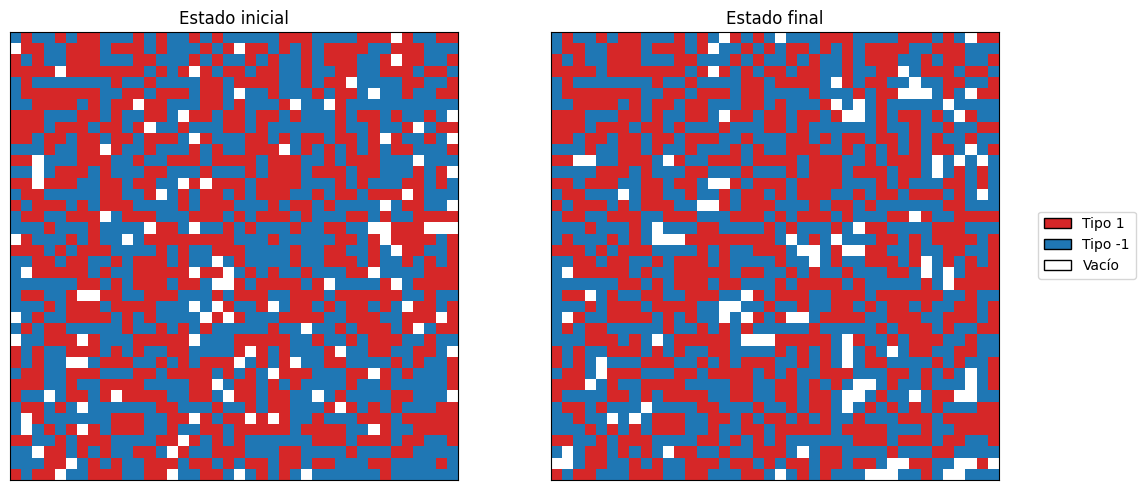

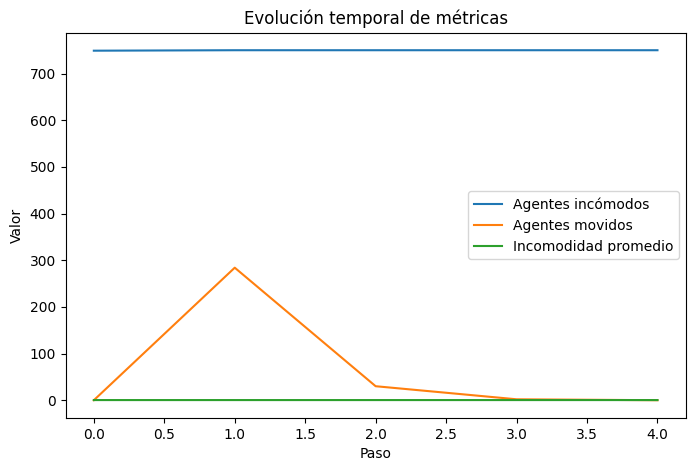

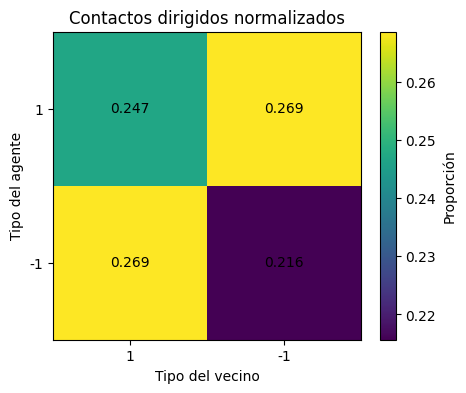

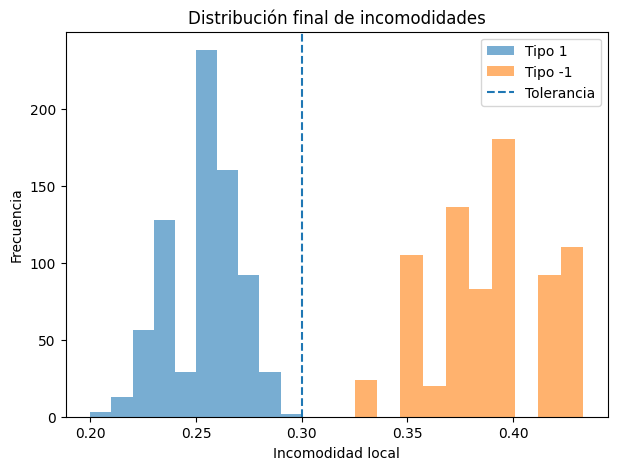

,Steps_to_Equilibrium,In_Equilibrium,Moved_Total,Unsatisfied_Total,Unsatisfied_1,Unsatisfied_-1,Mean_Discomfort,Mean_Discomfort_1,Mean_Discomfort_-1,C_11,C_1m1,C_m11,C_m1m1
0,0,False,0,749,0,749,0.325068,0.250128,0.400008,0.249111,0.250267,0.250267,0.250356
1,1,False,284,750,0,750,0.321254,0.252353,0.390154,0.247264,0.268002,0.268002,0.216731
2,2,False,30,750,0,750,0.321100,0.252433,0.389767,0.246959,0.268553,0.268553,0.215935
3,3,False,2,750,0,750,0.321084,0.252440,0.389727,0.247046,0.268648,0.268648,0.215659
4,3,True,0,750,0,750,0.321084,0.252440,0.389727,0.247046,0.268648,0.268648,0.215659


In [4]:
# ============================================================
# EXPERIMENTO INDIVIDUAL
# ============================================================

# ----------------------------
# Parámetros modificables
# ----------------------------

N1 =  750         # número de agentes de tipo 1
Nm1 = 750         # número de agentes de tipo -1

WIDTH = 40
HEIGHT = 40

TOL = 0.3       # tolerancia común
MAX_STEPS = 200

# Si queremos comparar diferentes matrices H partiendo de la misma condición inicial, entonces deja la semilla fija:
SEED_EXP = 231
# Si querems que cada corrida tenga un estado inicial distinto, cambiamos a:

#SEED_EXP = None


# Matriz de incomodidad H.
# Orden de tipos:
# fila/columna 0 -> tipo 1
# fila/columna 1 -> tipo -1

alpha = 0.2
beta = 0.3
gamma = 0.5

H = np.array([
    [alpha, beta],
    [beta, gamma]
], dtype=float)

# Ejemplos rápidos:
#
# Caso clásico:
# H = np.array([[0, 1],
#               [1, 0]], dtype=float)
#
# Caso homofílico simétrico con diagonales iguales:
# H = np.array([[0.2, 0.8],
#               [0.8, 0.2]], dtype=float)
#
# Caso heterofílico simétrico con diagonales iguales:
# H = np.array([[0.8, 0.2],
#               [0.2, 0.8]], dtype=float)
#
# Caso simétrico con diagonales distintas:
# H = np.array([[0.2, 0.8],
#               [0.8, 0.5]], dtype=float)


# ============================================================
# FUNCIONES AUXILIARES PARA VISUALIZACIÓN
# ============================================================

def estado_grid(modelo):
    """
    Convierte la grilla del modelo en un arreglo 2D.

    Valores:
        1  -> agente tipo 1
       -1  -> agente tipo -1
        0  -> celda vacía
    """

    estado = np.zeros((modelo.grid.height, modelo.grid.width), dtype=int)

    for agent in modelo.agents:
        x, y = agent.pos
        estado[y, x] = agent.tipo

    return estado


def graficar_estado(estado, titulo="Estado del sistema"):
    """
    Grafica una configuración espacial del modelo.
    """

    cmap = ListedColormap(["tab:blue", "white", "tab:red"])
    norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)

    plt.figure(figsize=(6, 6))
    plt.imshow(estado, cmap=cmap, norm=norm, origin="lower")

    plt.xticks([])
    plt.yticks([])
    plt.title(titulo)

    leyenda = [
        Patch(facecolor="tab:red", edgecolor="black", label="Tipo 1"),
        Patch(facecolor="tab:blue", edgecolor="black", label="Tipo -1"),
        Patch(facecolor="white", edgecolor="black", label="Vacío")
    ]

    plt.legend(
        handles=leyenda,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )

    plt.show()


def graficar_estado_inicial_final(estado_inicial, estado_final):
    """
    Grafica el estado inicial y el estado final del proceso.
    """

    cmap = ListedColormap(["tab:blue", "white", "tab:red"])
    norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    axes[0].imshow(estado_inicial, cmap=cmap, norm=norm, origin="lower")
    axes[0].set_title("Estado inicial")
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    axes[1].imshow(estado_final, cmap=cmap, norm=norm, origin="lower")
    axes[1].set_title("Estado final")
    axes[1].set_xticks([])
    axes[1].set_yticks([])

    leyenda = [
        Patch(facecolor="tab:red", edgecolor="black", label="Tipo 1"),
        Patch(facecolor="tab:blue", edgecolor="black", label="Tipo -1"),
        Patch(facecolor="white", edgecolor="black", label="Vacío")
    ]

    fig.legend(
        handles=leyenda,
        loc="center right",
        bbox_to_anchor=(1.08, 0.5)
    )

    plt.tight_layout()
    plt.show()


def graficar_metricas_temporales(datos):
    """
    Grafica algunas métricas globales a lo largo del tiempo.
    """

    plt.figure(figsize=(8, 5))

    if "Unsatisfied_Total" in datos.columns:
        plt.plot(datos.index, datos["Unsatisfied_Total"], label="Agentes incómodos")

    if "Moved_Total" in datos.columns:
        plt.plot(datos.index, datos["Moved_Total"], label="Agentes movidos")

    if "Mean_Discomfort" in datos.columns:
        plt.plot(datos.index, datos["Mean_Discomfort"], label="Incomodidad promedio")

    plt.xlabel("Paso")
    plt.ylabel("Valor")
    plt.title("Evolución temporal de métricas")
    plt.legend()
    plt.show()


def graficar_contactos_finales(modelo):
    """
    Grafica la matriz de contactos dirigidos normalizados al final del proceso.
    """

    C = np.array([
        [modelo.contact_measure[1][1],  modelo.contact_measure[1][-1]],
        [modelo.contact_measure[-1][1], modelo.contact_measure[-1][-1]]
    ])

    etiquetas = ["1", "-1"]

    plt.figure(figsize=(5, 4))
    plt.imshow(C, origin="upper")

    plt.xticks([0, 1], etiquetas)
    plt.yticks([0, 1], etiquetas)

    plt.xlabel("Tipo del vecino")
    plt.ylabel("Tipo del agente")
    plt.title("Contactos dirigidos normalizados")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, f"{C[i, j]:.3f}", ha="center", va="center")

    plt.colorbar(label="Proporción")
    plt.show()


def graficar_histograma_incomodidades(modelo):
    """
    Grafica la distribución final de incomodidades locales.
    """

    incomodidades_1 = []
    incomodidades_m1 = []

    for agent in modelo.agents:
        I = agent.incomodidad(agent.pos, agent.tipo)

        if agent.tipo == 1:
            incomodidades_1.append(I)
        elif agent.tipo == -1:
            incomodidades_m1.append(I)

    plt.figure(figsize=(7, 5))

    plt.hist(
        incomodidades_1,
        alpha=0.6,
        label="Tipo 1",
        bins=10
    )

    plt.hist(
        incomodidades_m1,
        alpha=0.6,
        label="Tipo -1",
        bins=10
    )

    plt.axvline(
        modelo.tolerance if not isinstance(modelo.tolerance, dict) else modelo.tolerance[1],
        linestyle="--",
        label="Tolerancia"
    )

    plt.xlabel("Incomodidad local")
    plt.ylabel("Frecuencia")
    plt.title("Distribución final de incomodidades")
    plt.legend()
    plt.show()


# ============================================================
# FUNCIÓN PRINCIPAL DEL EXPERIMENTO
# ============================================================

def correr_experimento(
    N1,
    Nm1,
    width,
    height,
    H,
    tol,
    max_steps=200,
    seed=None,
    mostrar_graficos=True
):
    """
    Corre un experimento individual del modelo matricial de Schelling.

    Retorna:
        modelo: objeto final del modelo.
        datos: DataFrame con las métricas recolectadas.
        estado_inicial: arreglo 2D con la configuración inicial.
        estado_final: arreglo 2D con la configuración final.
    """

    modelo = Modelo_Desplazamiento(
        N1=N1,
        Nm1=Nm1,
        width=width,
        height=height,
        H=H,
        tol=tol,
        seed=seed,
        collect_initial=True
    )

    estado_inicial = estado_grid(modelo)

    for _ in range(max_steps):
        if modelo.running:
            modelo.step()
        else:
            break

    estado_final = estado_grid(modelo)

    datos = modelo.datacollector.get_model_vars_dataframe()

    if mostrar_graficos:
        print("============================================================")
        print("Resumen del experimento")
        print("============================================================")
        print(f"N1 = {N1}")
        print(f"Nm1 = {Nm1}")
        print(f"Grilla = {width} x {height}")
        print(f"Tolerancia = {tol}")
        print("Matriz H:")
        print(H)
        print(f"Pasos ejecutados = {len(datos) - 1}")
        print(f"Equilibrio alcanzado = {modelo.in_equilibrium}")
        print(f"Agentes incómodos finales = {modelo.unsatisfied_count}")
        print(f"Incomodidad promedio final = {modelo.mean_discomfort:.4f}")

        graficar_estado_inicial_final(estado_inicial, estado_final)
        graficar_metricas_temporales(datos)
        graficar_contactos_finales(modelo)
        graficar_histograma_incomodidades(modelo)

    return modelo, datos, estado_inicial, estado_final


# ============================================================
# CORRER EXPERIMENTO
# ============================================================

modelo, datos, estado_inicial, estado_final = correr_experimento(
    N1=N1,
    Nm1=Nm1,
    width=WIDTH,
    height=HEIGHT,
    H=H,
    tol=TOL,
    max_steps=MAX_STEPS,
    seed=SEED_EXP,
    mostrar_graficos=True
)

datos.head()